# Semaine 1 — Notebook 00  
# Incertitude de mesure et bruit capteur

Ce notebook introduit les premières notions indispensables pour la fusion de capteurs et les filtres de Kalman :

- mesure bruitée ;
- bruit gaussien ;
- moyenne ;
- variance ;
- écart-type ;
- comparaison de capteurs ;
- estimation d'une position réelle à partir de mesures imparfaites.

Le cas étudié est volontairement simple : un capteur GPS mesure la position d'un véhicule immobile.

## 1. Objectif du notebook

Dans un système embarqué, un capteur ne fournit jamais directement la vérité physique.  
Il fournit une **mesure bruitée**.

On modélise cela par :

$$z = x + v$$

avec :

- $z$ : mesure fournie par le capteur ;
- $x$ : valeur réelle inconnue ;
- $v$ : bruit de mesure.

Dans ce notebook, nous allons simuler ce phénomène avec Python.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Simulation d'une position réelle

On considère un véhicule immobile situé à la position réelle :

$$x = 100 \ 	ext{m}$$

Le GPS va mesurer cette position avec une erreur aléatoire.

In [8]:
true_position = 100.0  # meters
n_measurements = 100

true_position

100.0

## 3. Simulation d'un GPS bruité

On suppose que le bruit du GPS suit une loi normale centrée :

$$v \sim \mathcal{N}(0, \sigma^2)$$

Ici, on prend :

$$\sigma = 2 \ 	ext{m}$$

Cela signifie que l'erreur typique du GPS est de l'ordre de 2 mètres.

In [11]:
gps_sigma = 2.0
noise = np.random.normal(loc=0.0, scale=gps_sigma, size=n_measurements)
gps_measurements = true_position + noise

gps_measurements[:10]

array([100.99342831,  99.7234714 , 101.29537708, 103.04605971,
        99.53169325,  99.53172609, 103.15842563, 101.53486946,
        99.06105123, 101.08512009])

## 4. Visualisation des mesures GPS

La ligne horizontale représente la position réelle.  
Les points représentent les mesures GPS bruitées.

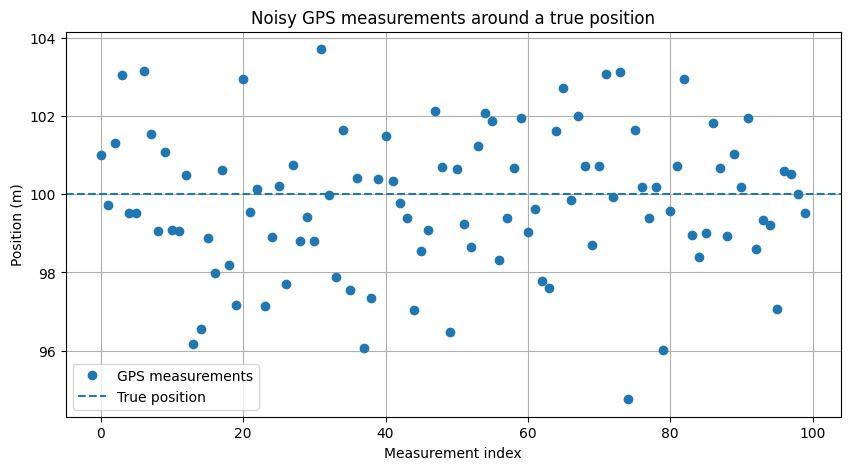

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(gps_measurements, marker='o', linestyle='none', label='GPS measurements')
plt.axhline(true_position, linestyle='--', label='True position')
plt.xlabel('Measurement index')
plt.ylabel('Position (m)')
plt.title('Noisy GPS measurements around a true position')
plt.legend()
plt.grid(True)
plt.show()

## 5. Moyenne des mesures

La moyenne des mesures fournit une première estimation de la position réelle.

$$\hat{x} = rac{1}{N}\sum_{i=1}^{N} z_i$$

In [17]:
estimated_position = np.mean(gps_measurements)
estimation_error = estimated_position - true_position

print(f"True position:      {true_position:.2f} m")
print(f"Estimated position: {estimated_position:.2f} m")
print(f"Estimation error:   {estimation_error:.2f} m")

True position:      100.00 m
Estimated position: 99.79 m
Estimation error:   -0.21 m


## 6. Variance et écart-type

La variance mesure la dispersion des mesures autour de leur moyenne.

L'écart-type est plus directement interprétable, car il est exprimé dans la même unité que la grandeur mesurée.

In [20]:
measurement_variance = np.var(gps_measurements, ddof=1)
measurement_std = np.std(gps_measurements, ddof=1)

print(f"Sample variance:          {measurement_variance:.2f} m²")
print(f"Sample standard deviation: {measurement_std:.2f} m")
print(f"Expected standard deviation: {gps_sigma:.2f} m")

Sample variance:          3.30 m²
Sample standard deviation: 1.82 m
Expected standard deviation: 2.00 m


## 7. Histogramme des mesures

L'histogramme permet de visualiser la distribution des mesures.

Si le bruit est gaussien, les mesures doivent être concentrées autour de la position réelle avec une forme proche d'une courbe en cloche.

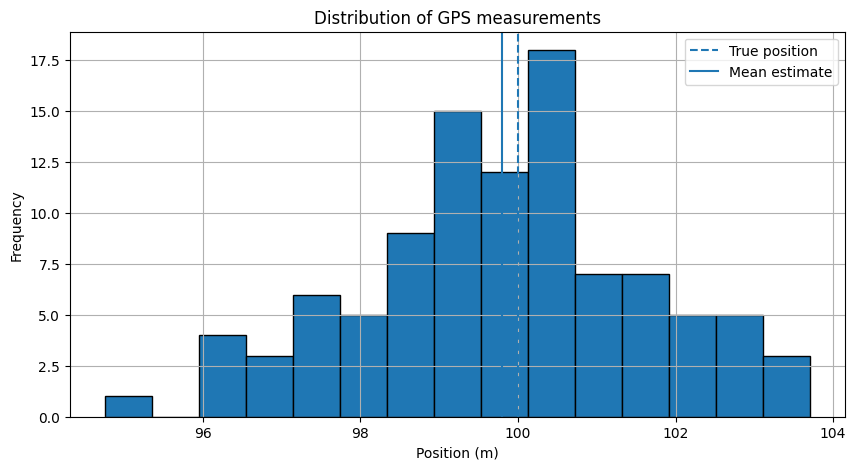

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(gps_measurements, bins=15, edgecolor='black')
plt.axvline(true_position, linestyle='--', label='True position')
plt.axvline(estimated_position, linestyle='-', label='Mean estimate')
plt.xlabel('Position (m)')
plt.ylabel('Frequency')
plt.title('Distribution of GPS measurements')
plt.legend()
plt.grid(True)
plt.show()

## 8. Effet du nombre de mesures

Plus le nombre de mesures augmente, plus la moyenne estimée se stabilise.

On calcule ici la moyenne cumulée des mesures.

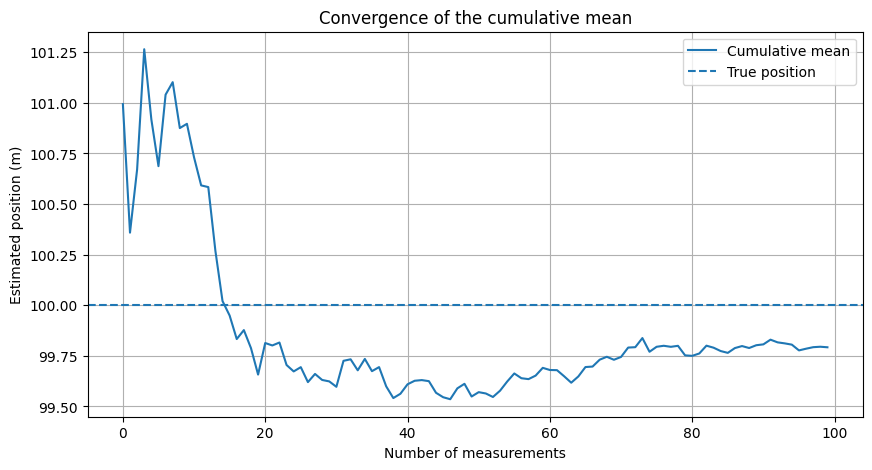

In [26]:
cumulative_mean = np.cumsum(gps_measurements) / np.arange(1, n_measurements + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_mean, label='Cumulative mean')
plt.axhline(true_position, linestyle='--', label='True position')
plt.xlabel('Number of measurements')
plt.ylabel('Estimated position (m)')
plt.title('Convergence of the cumulative mean')
plt.legend()
plt.grid(True)
plt.show()

## 9. Comparaison de deux capteurs

On compare maintenant deux GPS :

- GPS A : faible bruit, donc plus précis ;
- GPS B : bruit plus fort, donc moins précis.

Les deux capteurs mesurent la même position réelle.

In [31]:
gps_a_sigma = 1.0
gps_b_sigma = 5.0

measurements_a = true_position + np.random.normal(0, gps_a_sigma, n_measurements)
measurements_b = true_position + np.random.normal(0, gps_b_sigma, n_measurements)

print("GPS A")
print(f"Mean: {np.mean(measurements_a):.2f} m")
print(f"Std:  {np.std(measurements_a, ddof=1):.2f} m")

print("GPS B")
print(f"Mean: {np.mean(measurements_b):.2f} m")
print(f"Std:  {np.std(measurements_b, ddof=1):.2f} m")

GPS A
Mean: 100.02 m
Std:  0.95 m
GPS B
Mean: 100.32 m
Std:  5.42 m


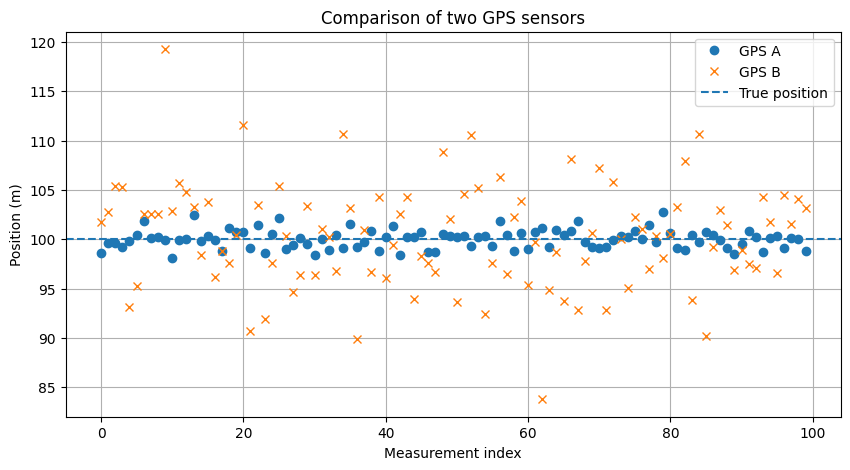

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(measurements_a, marker='o', linestyle='none', label='GPS A')
plt.plot(measurements_b, marker='x', linestyle='none', label='GPS B')
plt.axhline(true_position, linestyle='--', label='True position')
plt.xlabel('Measurement index')
plt.ylabel('Position (m)')
plt.title('Comparison of two GPS sensors')
plt.legend()
plt.grid(True)
plt.show()

## 10. Première intuition de fusion de capteurs

Si deux capteurs mesurent la même grandeur, mais avec des incertitudes différentes, il n'est pas optimal de faire une simple moyenne.

Le capteur le plus précis doit avoir plus de poids.

Une estimation pondérée peut s'écrire :

$$\hat{x} = rac{w_A z_A + w_B z_B}{w_A + w_B}$$

Dans un cadre probabiliste, les poids sont liés à l'inverse de la variance :

$$w = rac{1}{\sigma^2}$$

Donc, plus la variance est faible, plus le capteur est fiable.

In [36]:
z_a = np.mean(measurements_a)
z_b = np.mean(measurements_b)

var_a = np.var(measurements_a, ddof=1)
var_b = np.var(measurements_b, ddof=1)

w_a = 1 / var_a
w_b = 1 / var_b

simple_average = (z_a + z_b) / 2
weighted_estimate = (w_a * z_a + w_b * z_b) / (w_a + w_b)

print(f"True position:       {true_position:.2f} m")
print(f"GPS A mean:          {z_a:.2f} m")
print(f"GPS B mean:          {z_b:.2f} m")
print(f"Simple average:      {simple_average:.2f} m")
print(f"Weighted estimate:   {weighted_estimate:.2f} m")

True position:       100.00 m
GPS A mean:          100.02 m
GPS B mean:          100.32 m
Simple average:      100.17 m
Weighted estimate:   100.03 m


## 11. Interprétation

Ce mécanisme est une première intuition du filtre de Kalman.

Le filtre de Kalman combine :

- une prédiction issue d'un modèle physique ;
- une mesure issue d'un capteur ;
- l'incertitude de la prédiction ;
- l'incertitude de la mesure.

La mesure la plus fiable influence davantage l'estimation finale.

## 12. Exercices

### Exercice 1

Modifier `gps_sigma` avec les valeurs suivantes :

- 0.5 m ;
- 2 m ;
- 10 m.

Observer l'effet sur :

- les mesures ;
- l'histogramme ;
- l'estimation moyenne ;
- l'écart-type.

### Exercice 2

Augmenter `n_measurements` :

- 10 ;
- 100 ;
- 1000 ;
- 10000.

Observer la convergence de la moyenne.

### Exercice 3

Créer un troisième capteur GPS C avec :

$$\sigma_C = 0.5 \ 	ext{m}$$

Comparer son estimation avec GPS A et GPS B.

### Exercice 4

Implémenter une fusion pondérée avec trois capteurs.

### Exercice 5

Expliquer pourquoi un capteur très bruité ne doit pas avoir le même poids qu'un capteur précis.

## 13. Résumé

À retenir :

- une mesure capteur est une approximation bruitée de la réalité ;
- le bruit peut être modélisé par une variable aléatoire ;
- la moyenne permet d'estimer une grandeur fixe ;
- la variance mesure l'incertitude ;
- l'écart-type donne une interprétation physique de cette incertitude ;
- la fusion de capteurs doit tenir compte de la fiabilité de chaque capteur.

Ces notions seront réutilisées directement dans les modèles d'état et le filtre de Kalman.